In [155]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
from topocalc.skew import adjust_spacing, skew

In [254]:
def nan_a_tab(tab : np.ndarray, max_index : int, fwd : bool):
    
    a,b = tab.shape
    
    res = tab.copy()
    
    if fwd :
    
        for j in range(b):
            for i in range(j,a):
                if i > j + max_index :
                    res[i,j]=np.nan
                    
    else :
        
        for j in range(b):
            for i in range(j,0,-1):
                if i < j - max_index :
                    res[i,j]=np.nan  
                
    return res

def pyhorizon_Radius(dem : np.ndarray, dx : float, max_length : float, max_threshold : bool, fwd : bool):
    """
    From Topocalc github repo : https://github.com/USDA-ARS-NWRC/topocalc/blob/main/topocalc/horizon.py
    Modify so that radius of horizon angle investigation is in input
    
    Pure python version of the horizon function.

    NOTE: this is fast for small dem's but quite slow
    for larger ones. This is mainly to show that it
    can be done with numpy but requires a bit more to
    remove the for loop over the rows. Also, this just
    calculates the horizon in one direction, need to implement
    the rest of the horizon function for calcuating the
    horizon at an angle.

    Args:
        dem (np.ndarray): dem for the horizon
        dx (float): spacing for the dem

    Returns:
        [tuple]: cosine of the horizon angle and index
            to the horizon.
    """

    # needs to be a float
    if dem.dtype != np.float64:
        dem = dem.astype(np.float64)
        
    # Maximum index 
    max_index = int(max_length // dx)

    nrows, ncols = dem.shape
    hcos = np.zeros_like(dem)
    horizon_index = np.zeros_like(dem)

    # distance to each point
    # k=-1 because the distance to the point itself is 0
    distance = dx * np.cumsum(np.tri(ncols, ncols, k=-1), axis=0)
    col_index = np.arange(0, ncols)
        
    for n in range(nrows):
        if fwd :
            surface = dem[n, :]
        else :
            surface = dem[n, ::-1]

        m = np.repeat(surface.reshape(1, -1), ncols, axis=0)
        
        #height change
        height = np.tril(m.T - m)
   
        # slope
        slope = height / distance
        
        # Added line so that the research for maximal slope stop after max_index_columns
        if max_threshold :
            slope = nan_a_tab(tab = slope, max_index = max_index, fwd = True)
            
        hor = np.nanargmax(slope[:, :-1], axis=0)

        hor = np.append(hor, ncols-1)
        hidx = hor.astype(int)

        horizon_height_diff = surface[hidx] - surface
        horizon_distance_diff = dx * (hor - col_index)

        new_horizon = horizon_height_diff / \
            np.sqrt(horizon_height_diff**2 + horizon_distance_diff**2)

        new_horizon[new_horizon < 0] = 0
        new_horizon[np.isnan(new_horizon)] = 0

        hcos[n, :] = new_horizon
        horizon_index[n, :] = hidx

    if fwd :
        return hcos, horizon_index
    
    else :
        return hcos[:,::-1], horizon_index[:,::-1]

In [197]:
topo_params = xr.open_dataset("/home/barroisl/radiation_baseline/netcdfs/topo_params.nc")

In [255]:
hcos_l, horizon_index_l = pyhorizon_Radius(dem = topo_params.ZS.values, dx = 30.0, \
                                       max_length = 1000.0, max_threshold = True, fwd = True)

hcos_u, horizon_index_u = pyhorizon_Radius(dem = topo_params.ZS.values, dx = 30.0, \
                                       max_length = 1000.0, max_threshold = True, fwd = False)

/tmp/ipykernel_42088/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_42088/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \


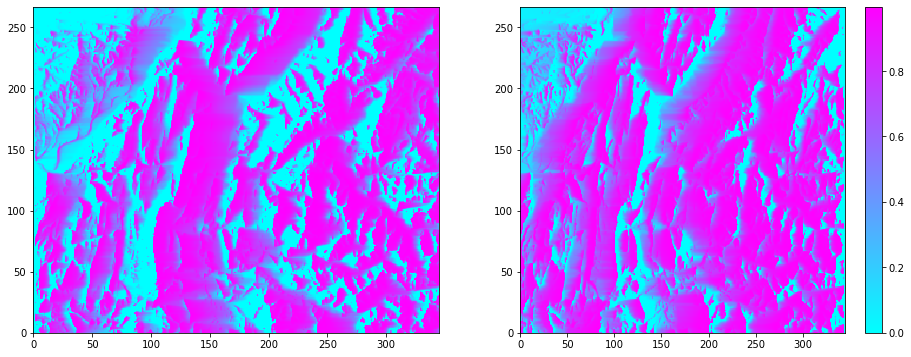

In [256]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

cax = axs[0].pcolormesh(hcos_u, cmap = 'cool')
cax = axs[1].pcolormesh(hcos_l, cmap = 'cool')
fig.colorbar(mappable = cax)

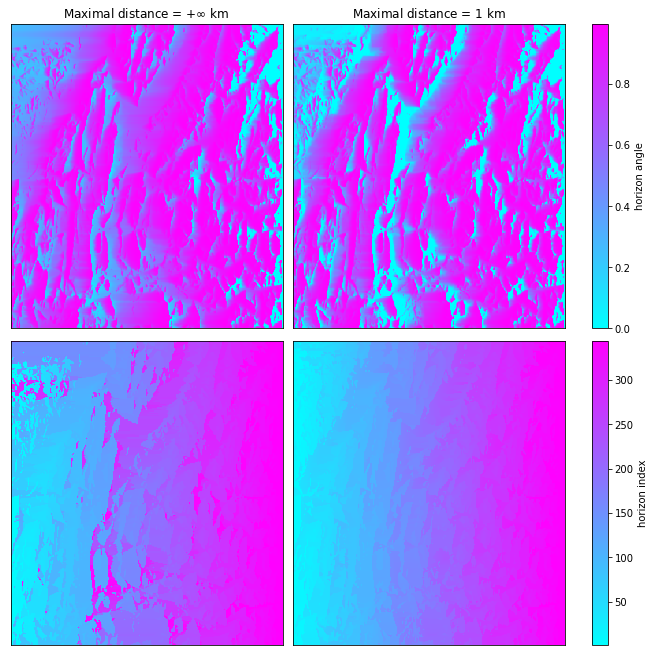

In [151]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9),layout = 'constrained')

im00=axs[0,0].pcolormesh(hcos,cmap = 'cool')
im01=axs[0,1].pcolormesh(hcos_,cmap = 'cool')
fig.colorbar(mappable = im01, ax = axs[0], label = 'horizon angle')

im10=axs[1,0].pcolormesh(horizon_index,cmap = 'cool')
im11=axs[1,1].pcolormesh(horizon_index_,cmap = 'cool')
fig.colorbar(mappable = im11, ax = axs[1], label = 'horizon index')

axs[0,0].set_title('Maximal distance = $+\infty$ km')
axs[0,1].set_title('Maximal distance = $1$ km')

for i in range(4) :
    
    ax = axs[i//2,i%2]
    
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.savefig("/home/barroisl/Transect_MC_auto/Output/test_horizon_max_dist.png")

In [257]:
def skew_transpose(dem, spacing, angle):
    """Skew and transpose the dem for the given angle.
    Also calculate the new spacing given the skew.

    Arguments:
        dem {array} -- numpy array of dem elevations
        spacing {float} -- grid spacing
        angle {float} -- skew angle

    Returns:
        t -- skew and transpose array
        spacing -- new spacing adjusted for angle
    """

    spacing = adjust_spacing(spacing, np.abs(angle))
    t = skew(dem, angle, fill_min=True).transpose()

    return t, spacing

def horizon(azimuth : float, dem : np.ndarray, spacing : float, max_length : float, max_threshold : bool):
    """Calculate horizon angles for one direction. Horizon angles
    are based on Dozier and Frew 1990 and are adapted from the
    IPW C code.

    The coordinate system for the azimuth is 0 degrees is South,
    with positive angles through East and negative values
    through West. Azimuth values must be on the -180 -> 0 -> 180
    range.

    Arguments:
        azimuth {float} -- find horizon's along this direction
        dem {np.array2d} -- numpy array of dem elevations
        spacing {float} -- grid spacing

    Returns:
        hcos {np.array} -- cosines of angles to the horizon
    """

    if dem.ndim != 2:
        raise ValueError('horizon input of dem is not a 2D array')

    if azimuth > 180 or azimuth < -180:
        raise ValueError('azimuth must be between -180 and 180 degrees')
        

    if azimuth == 90:
        # East
        hcos,_ = pyhorizon_Radius(dem = dem, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        #hor2d_c(dem, spacing, fwd=True)

    elif azimuth == -90:
        # West
        #hcos = hor2d_c(dem, spacing, fwd=False)
        hcos,_ = pyhorizon_Radius(dem = dem, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)

    elif azimuth == 0:
        # South
        h,_ = pyhorizon_Radius(dem = dem.transpose(), dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = h.transpose()
        #hcos = hor2d_c(dem.transpose(), spacing, fwd=True)

    elif np.abs(azimuth) == 180:
        # South
        #hcos = hor2d_c(dem.transpose(), spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = dem.transpose(), dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = h.transpose()

    elif azimuth >= -45 and azimuth <= 45:
        # South west through south east
        t, spacing = skew_transpose(dem, spacing, azimuth)
        #h = hor2d_c(t, spacing, fwd=True)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = skew(h.transpose(), azimuth, fwd=False)

    elif azimuth <= -135 and azimuth > -180:
        # North west
        a = azimuth + 180
        t, spacing = skew_transpose(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False)

    elif azimuth >= 135 and azimuth < 180:
        # North East
        a = azimuth - 180
        t, spacing = skew_transpose(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False)

    elif azimuth > 45 and azimuth < 135:
        # South east through north east
        a = 90 - azimuth
        t, spacing = transpose_skew(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=True)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = skew(h.transpose(), a, fwd=False).transpose()

    elif azimuth < -45 and azimuth > -135:
        # South west through north west
        a = -90 - azimuth
        t, spacing = transpose_skew(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False).transpose()

    else:
        ValueError('azimuth not valid')

    # sanity check
    assert hcos.shape == dem.shape

    return hcos

In [275]:
hcos_180 = horizon(azimuth = -160, dem = topo_params.ZS.values, spacing = 30.0, \
                                       max_length = 2000, max_threshold = True)
hcos_90 = horizon(azimuth = 160, dem = topo_params.ZS.values, spacing = 30.0, \
                                       max_length = 2000, max_threshold = True)

/tmp/ipykernel_42088/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_42088/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \


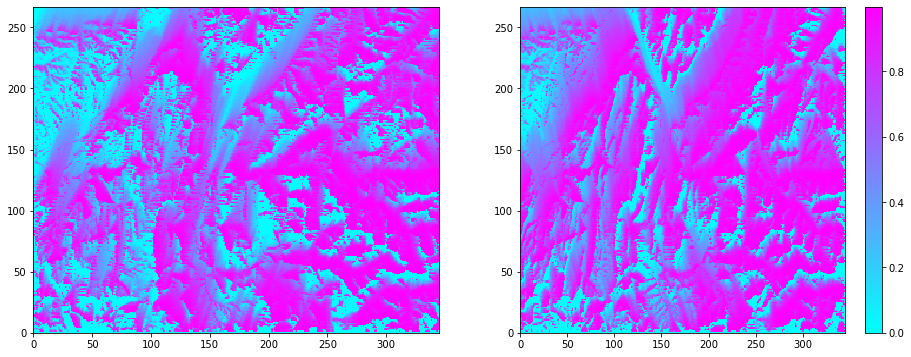

In [276]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

cax = axs[0].pcolormesh(hcos_180, cmap = 'cool')
cax = axs[1].pcolormesh(hcos_90, cmap = 'cool')
fig.colorbar(mappable = cax)